# 05 – Model: Competition Prediction

### Purpose
Prediction of the number of offers using ML models.

### Steps
- Feature-Auswahl
- Modelltraining
- Evaluation
- Feature Importance


--------------------
#### Imports & Setup
-------------------

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import pickle
import json

import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# importing modules for data preparation
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# importing modules for training
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report

# importing modules for pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# importing modules for hyperparameter optimization and comparison of models
from sklearn.model_selection import validation_curve, learning_curve


In [2]:
# shut off some annoying warnings
import warnings

warnings.filterwarnings("ignore", message="A value is trying to be set on a copy")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# ---------------------------------------------------------
# Setup style
# ---------------------------------------------------------

# show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# visualisation settings
pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
# ---------------------------------------------------------
# Load scripts
# ----------------------------------------------------------

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# found min directory
PROJECT_ROOT = Path("..").resolve()

# maindirectory sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# import function from script
from my_scripts.model_building import (fit_encoder, transform_with_encoder, train_model, tune_logreg)

from my_scripts.eda import (overview, filter_germany)

from my_scripts.visualization import (plot_roc_curve, plot_pr_curve, plot_confusion_matrix, plot_feature_importance)

In [5]:
# ---------------------------------------------------------
# Load data and artifacts
# ---------------------------------------------------------

BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "dataset_nlp.pkl"
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "risk_model.pkl"
PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.pkl"
FEATURE_LIST_PATH = MODELS_DIR / "feature_list.json"
METRICS_PATH = MODELS_DIR / "metrics.json"

In [6]:
# Load dataset
with open(DATA_PATH, "rb") as f:
    df = pickle.load(f)

------------------------
# Modelling

-----------------

In [7]:
# ---------------------------------------------------------
# Create feature and test
# ---------------------------------------------------------

# delete "NUMBER_OFFERS"
df = df.drop(columns=["NUMBER_OFFERS", "TEXT_RISK_SCORE", "TEXT_RISK_LABEL", "TITLE", "TOPIC_NAME"]).reset_index(drop=True)

# Load feature info
TARGET_COL = "IS_FAILED_TENDER"

features = df.drop(columns=[TARGET_COL])
target = df[TARGET_COL]

In [8]:
df.head()

,YEAR,ISO_COUNTRY_CODE,TYPE_OF_CONTRACT,TOP_TYPE,AWARD_VALUE_EURO,CRIT_PRICE_WEIGHT,IS_FAILED_TENDER,AWARD_QUARTER,DAYS_TO_AWARD,CPV_CATEGORY,CAE_TYPE_CATEGORY,NLP_SVD_0,NLP_SVD_1,NLP_SVD_2,NLP_SVD_3,NLP_SVD_4,NLP_SVD_5,NLP_SVD_6,NLP_SVD_7,NLP_SVD_8,NLP_SVD_9,NLP_SVD_10,NLP_SVD_11,NLP_SVD_12,NLP_SVD_13,NLP_SVD_14,NLP_SVD_15,NLP_SVD_16,NLP_SVD_17,NLP_SVD_18,NLP_SVD_19,NLP_SVD_20,NLP_SVD_21,NLP_SVD_22,NLP_SVD_23,NLP_SVD_24,NLP_SVD_25,NLP_SVD_26,NLP_SVD_27,NLP_SVD_28,NLP_SVD_29,NLP_SVD_30,NLP_SVD_31,NLP_SVD_32,NLP_SVD_33,NLP_SVD_34,NLP_SVD_35,NLP_SVD_36,NLP_SVD_37,NLP_SVD_38,NLP_SVD_39,NLP_SVD_40,NLP_SVD_41,NLP_SVD_42,NLP_SVD_43,NLP_SVD_44,NLP_SVD_45,NLP_SVD_46,NLP_SVD_47,NLP_SVD_48,NLP_SVD_49,NLP_SVD_50,NLP_SVD_51,NLP_SVD_52,NLP_SVD_53,NLP_SVD_54,NLP_SVD_55,NLP_SVD_56,NLP_SVD_57,NLP_SVD_58,NLP_SVD_59,NLP_SVD_60,NLP_SVD_61,NLP_SVD_62,NLP_SVD_63,NLP_SVD_64,NLP_SVD_65,NLP_SVD_66,NLP_SVD_67,NLP_SVD_68,NLP_SVD_69,NLP_SVD_70,NLP_SVD_71,NLP_SVD_72,NLP_SVD_73,NLP_SVD_74,NLP_SVD_75,NLP_SVD_76,NLP_SVD_77,NLP_SVD_78,NLP_SVD_79,NLP_SVD_80,NLP_SVD_81,NLP_SVD_82,NLP_SVD_83,NLP_SVD_84,NLP_SVD_85,NLP_SVD_86,NLP_SVD_87,NLP_SVD_88,NLP_SVD_89,NLP_SVD_90,NLP_SVD_91,NLP_SVD_92,NLP_SVD_93,NLP_SVD_94,NLP_SVD_95,NLP_SVD_96,NLP_SVD_97,NLP_SVD_98,NLP_SVD_99,NLP_TOPIC_0,NLP_TOPIC_1,NLP_TOPIC_2,NLP_TOPIC_3,NLP_TOPIC_4,NLP_TOPIC_5,NLP_TOPIC_6,NLP_TOPIC_7,NLP_TOPIC_8,NLP_TOPIC_9,NLP_TOPIC_10,NLP_TOPIC_11,NLP_TOPIC_12,NLP_TOPIC_13,NLP_TOPIC_14,TOPIC_ID
0,2008,DE,W,OPE,"302,964.15",1,0,3.00,73.00,Other,Public Undertaking,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
1,2008,DE,W,OPE,"478,780.08",0,0,4.00,6.00,Other,National Agency,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
2,2008,ES,W,OPE,"14,237,368.10",1,0,4.00,63.00,Other,Ministry,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
3,2008,DE,W,OPE,"5,204,457.56",1,0,4.00,27.00,Other,National Agency,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0

In [10]:
# ---------------------------------------------------------
# Categorical features encoding
# ---------------------------------------------------------

# fit encoder only on train
encoder = fit_encoder(features)

# transform train and test
features = transform_with_encoder(features, encoder)


In [11]:
# Train/test split

features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target)

-------------------------------------------------------------------
### Model pipeline

-------------------------------------------------------------------

In [12]:
# Logistic Regression
lr_model = train_model(LogisticRegression(max_iter=500, class_weight='balanced'), features_train, features_test, target_train, target_test)


=== Model: LogisticRegression ===
F1: 0.542733431352949
ROC-AUC: 0.7556057675514799
              precision    recall  f1-score   support

           0       0.87      0.70      0.78    445414
           1       0.45      0.69      0.54    155195

    accuracy                           0.70    600609
   macro avg       0.66      0.70      0.66    600609
weighted avg       0.76      0.70      0.72    600609



In [13]:
# Random Forest
rf_model = train_model(RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=4, random_state=42, class_weight='balanced'), 
                       features_train, features_test, target_train, target_test)


=== Model: RandomForestClassifier ===
F1: 0.544526517164417
ROC-AUC: 0.7606081631810312
              precision    recall  f1-score   support

           0       0.86      0.73      0.79    445414
           1       0.46      0.66      0.54    155195

    accuracy                           0.71    600609
   macro avg       0.66      0.70      0.67    600609
weighted avg       0.76      0.71      0.73    600609



In [14]:
# Gradient Boosting
gb_model = train_model(GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=2, random_state=42), 
                       features_train, features_test, target_train, target_test)


=== Model: GradientBoostingClassifier ===
F1: 0.1571045514435635
ROC-AUC: 0.7124758401469293
              precision    recall  f1-score   support

           0       0.76      0.99      0.86    445414
           1       0.76      0.09      0.16    155195

    accuracy                           0.76    600609
   macro avg       0.76      0.54      0.51    600609
weighted avg       0.76      0.76      0.68    600609



In [ ]:
# Hyperparameter tuning
# best_lr = tune_logreg(features_train, target_train) - MemoryError: Unable to allocate 1.68 GiB for an array with shape (100, 2252119

#### Notes: Why Logistic Regression was selected
Logistic Regression was chosen because it provides the highest recall for the minority class (low‑competition tenders), trains extremely fast on large datasets, and remains stable without hyperparameter tuning.  
In this project, recall is the priority: missing a risky tender (false negative) is more harmful than incorrectly flagging a safe one.
Among baseline models tested, Logistic Regression achieved the best recall while maintaining good overall performance and computational efficiency.

# Model evaluation

<Figure size 700x500 with 0 Axes>

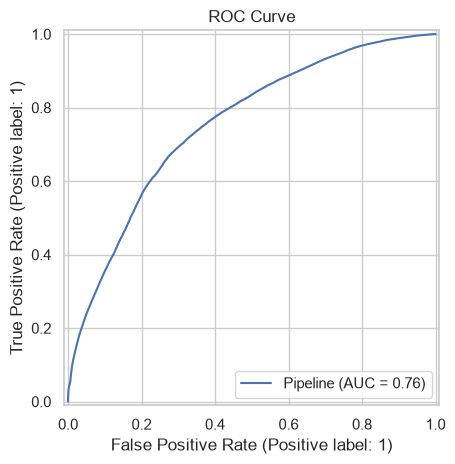

In [15]:
# ROC Curve

plot_roc_curve(
    model=lr_model,
    features_test=features_test,
    target_test=target_test,
    save=True
)

<Figure size 700x500 with 0 Axes>

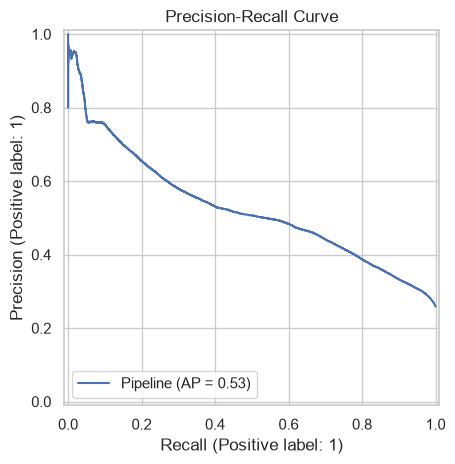

In [16]:
# Precision–Recall Curve

plot_pr_curve(
    model=lr_model,
    features_test=features_test,
    target_test=target_test,
    save=True
)


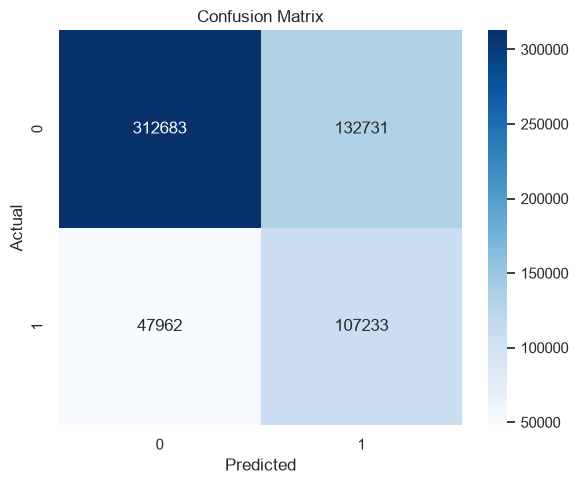

In [17]:
# Confusion Matrix

plot_confusion_matrix(
    model=lr_model,
    features_test=features_test,
    target_test=target_test,
    save=True
)


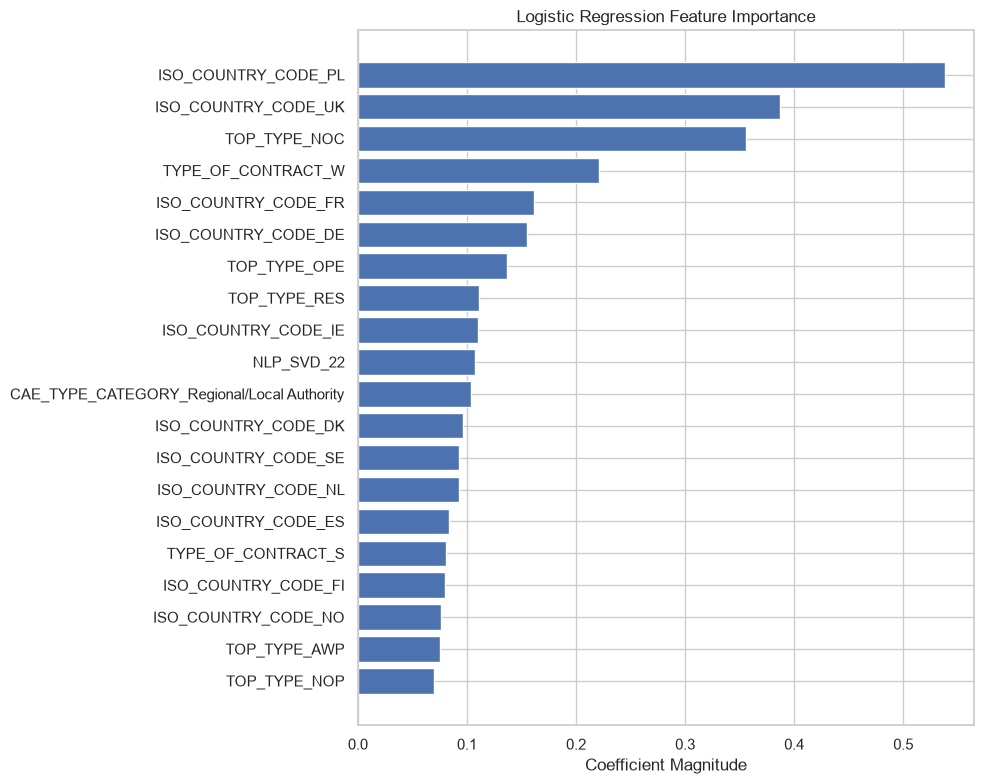

In [19]:
# Plot
imp_lr = plot_feature_importance(
    pipeline=lr_model,
    feature_names=features_train.columns,
    top_n=20
)




In [20]:
# Save model Logistic Regression

with open("../models/lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)



In [21]:
# Save model Random Forest 

with open("../models/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
